# 03_01 — FFT Model Training: Fluxo Passo a Passo

**Pipeline:** `fft_model_training`  
**Kedro nodes:** `fft_build_training_data_node` → `fft_fit_and_scale_node` → `fft_train_isolation_forest_node` → `fft_evaluate_model_node`  
**Input catalog:** `fft_feature_engineered_flights` (data/04_feature/fft/)  
**Output catalog:** `fft_isolation_forest`, `fft_feature_scaler`, `fft_model_metrics`, `fft_selected_features`

---

## Contexto

Este notebook documenta o fluxo do pipeline `fft_model_training`, análogo ao `03_00` para
o pipeline `model_training`. A diferença fundamental está nas **features de entrada**:

| Pipeline | Features | Sinais de origem |
|---|---|---|
| `model_training` | Rolling stats sobre todos os sinais preparados | ~40 colunas após data_preparation |
| `fft_model_training` | Rolling stats + descritores espectrais FFT | 7 sinais com vínculo físico ao motor |

### Sinais usados pelo pipeline FFT

| Sinal | Família | Razão física |
|---|---|---|
| `imu_accel_x/y/z` | Vibração | Desequilíbrio mecânico do motor gera vibração periódica |
| `mag_x/y/z` | Campo EM | Campo magnético do motor varia com a rotação |
| `aspd_meas` | Empuxo | Oscilação de empuxo cria ripple na velocidade do ar |

### Descritores por sinal

| Família | Descritor | Janelas |
|---|---|---|
| Rolling statistics | `mean`, `std`, `slope` | [50, 100, 200] amostras |
| FFT spectral | `peak_power`, `entropy`, `high_ratio` | [500, 1000, 2000] amostras |

### Diferença adicional em relação ao 03_00: RobustScaler

O pipeline `fft_model_training` inclui um nó `fft_fit_and_scale_node` (ausente no
`model_training` original) que aplica um `RobustScaler` antes do treino. O scaler
é persistido no catálogo (`fft_feature_scaler`) para reutilização na inferência.

### Fluxo do pipeline
1. **Skip inicial**: remove fase de transição de altitude (~20 s) de cada voo
2. **Seleção de features**: Cohen's d ranqueia features por separabilidade fault vs normal
3. **Sliding windows**: cada amostra = últimos `window_size` timesteps achatados
4. **RobustScaler**: ajustado no treino, aplicado no teste
5. **Treino**: Isolation Forest com split temporal 70/30
6. **Avaliação**: latência de detecção = tempo entre falha real e primeiro alerta

> **Para rodar toda a pipeline no Kedro:** `kedro run --pipeline=fft_model_training`

## Imports e parâmetros

In [1]:
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeroespacial_2.pipelines.fft_model_training.nodes import (
    create_windows,
    evaluate_model,
    fit_and_scale,
    select_top_features_effect_size,
    split_windows,
    train_isolation_forest,
)

_params = yaml.safe_load(
    (Path("../../conf/base/parameters.yml")).read_text()
)["fft_model_training"]

PREPARED_FILE  = "../../data/04_feature/fft/carbonZ_2018-07-18-15-53-31_1_engine_failure.csv"
WINDOW_SIZE    = _params["window_size"]
N_TOP_FEATURES = _params["n_top_features"]
CONTAMINATION  = _params["contamination"]
N_ESTIMATORS   = _params["n_estimators"]
MAX_SAMPLES    = _params["max_samples"]
MAX_FEATURES   = _params["max_features"]
TRAIN_RATIO    = _params["train_ratio"]
TARGET_COL     = _params["target_col"]
TIMESTAMP_COL  = _params["timestamp_col"]
SKIP_SECONDS   = _params.get("skip_seconds", 0.0)

print("Parâmetros carregados de conf/base/parameters.yml → fft_model_training:")
for k, v in _params.items():
    print(f"  {k}: {v}")

Parâmetros carregados de conf/base/parameters.yml → fft_model_training:
  window_size: 20
  contamination: 0.03
  n_estimators: 100
  max_samples: 128
  max_features: 1.0
  n_top_features: 20
  train_ratio: 0.7
  target_col: target_fault
  timestamp_col: timestamp
  skip_seconds: 20.0


In [2]:
df_raw = pd.read_csv(PREPARED_FILE)

# Remove a fase de transição inicial (aeronave descendo para altitude de cruise)
df = df_raw[df_raw[TIMESTAMP_COL] >= SKIP_SECONDS].copy() if SKIP_SECONDS > 0 else df_raw.copy()

print(f"Shape original: {df_raw.shape}  →  após skip {SKIP_SECONDS}s: {df.shape}")
print(f"Falhas: {df[TARGET_COL].sum():.0f} amostras ({df[TARGET_COL].mean()*100:.1f}%)")
print(f"\nFamílias de features presentes:")
feature_cols = [c for c in df.columns if c not in [TARGET_COL, TIMESTAMP_COL]]
families = {"rolling_mean": 0, "rolling_std": 0, "rolling_slope": 0,
            "fft_peak_power": 0, "fft_entropy": 0, "fft_high_ratio": 0}
for c in feature_cols:
    for fam in families:
        if fam in c:
            families[fam] += 1
for fam, count in families.items():
    print(f"  {fam}: {count} colunas")
print(f"  Total: {len(feature_cols)} features")
df.head(3)

Shape original: (25994, 136)  →  após skip 20.0s: (22031, 136)
Falhas: 3220 amostras (14.6%)

Famílias de features presentes:
  rolling_mean: 0 colunas
  rolling_std: 0 colunas
  rolling_slope: 0 colunas
  fft_peak_power: 21 colunas
  fft_entropy: 21 colunas
  fft_high_ratio: 21 colunas
  Total: 134 features


,timestamp,target_fault,alt_global,imu_accel_x,imu_accel_y,imu_accel_z,mag_x,mag_y,mag_z,aspd_meas,...,fft_high_ratio_mag_z_2000,fft_peak_power_aspd_meas_500,fft_entropy_aspd_meas_500,fft_high_ratio_aspd_meas_500,fft_peak_power_aspd_meas_1000,fft_entropy_aspd_meas_1000,fft_high_ratio_aspd_meas_1000,fft_peak_power_aspd_meas_2000,fft_entropy_aspd_meas_2000,fft_high_ratio_aspd_meas_2000
3963,20.001260,0.0,359.232698,0.323619,0.676659,8.963278,-133000.0,211000.0,-459000.0,15.379858,...,0.000223,128.226855,0.287755,0.003930,514.522073,0.119288,0.000576,1573.83256,0.120984,0.000126
3964,20.003843,0.0,359.232698,0.323619,0.676659,8.963278,-133000.0,211000.0,-459000.0,15.379858,...,0.000222,126.792200,0.288247,0.004055,513.946895,0.118814,0.000556,1573.95627,0.120939,0.000126
3965,20.006855,0.0,359.552754,0.323619,0.676659,8.963278,-133000.0,211000.0,-459000.0,15.379858,...,0.000221,125.352553,0.288674,0.004073,513.375994,0.118313,0.000566,1574.07875,0.120893,0.000126


## Passo 1 — Seleção de features com Cohen's d

Ranqueamos cada feature pelo **effect size de Cohen's d** entre as distribuições
de voo normal e de falha:

$$d = \frac{|\mu_{\text{falha}} - \mu_{\text{normal}}|}{\sigma_{\text{pooled}}}$$

Para features FFT, esperamos que descritores espectrais como `peak_power` e `high_ratio`
apareçam entre os mais discriminativos — eles capturam precursores de falha invisíveis
no domínio do tempo, como oscilações na frequência de rotação do motor antes da parada.

In [3]:
features = [c for c in df.columns if c not in [TARGET_COL, TIMESTAMP_COL]]
top_features = select_top_features_effect_size(df, features, TARGET_COL, n_top=N_TOP_FEATURES)

print(f"Top {N_TOP_FEATURES} features (Cohen's d):")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2d}. {f}")

Top 20 features (Cohen's d):
   1. alt_global
   2. aspd_meas
   3. aspd_meas_mean_50
   4. aspd_meas_mean_100
   5. aspd_meas_mean_200
   6. fft_peak_power_mag_z_2000
   7. fft_entropy_imu_accel_y_1000
   8. fft_peak_power_mag_x_1000
   9. fft_high_ratio_imu_accel_y_2000
  10. fft_entropy_imu_accel_z_2000
  11. fft_entropy_imu_accel_x_2000
  12. fft_high_ratio_imu_accel_y_1000
  13. fft_entropy_imu_accel_y_2000
  14. fft_peak_power_mag_z_1000
  15. mag_y_mean_200
  16. fft_peak_power_mag_x_500
  17. mag_y_mean_100
  18. mag_y_mean_50
  19. mag_y
  20. fft_entropy_mag_x_500


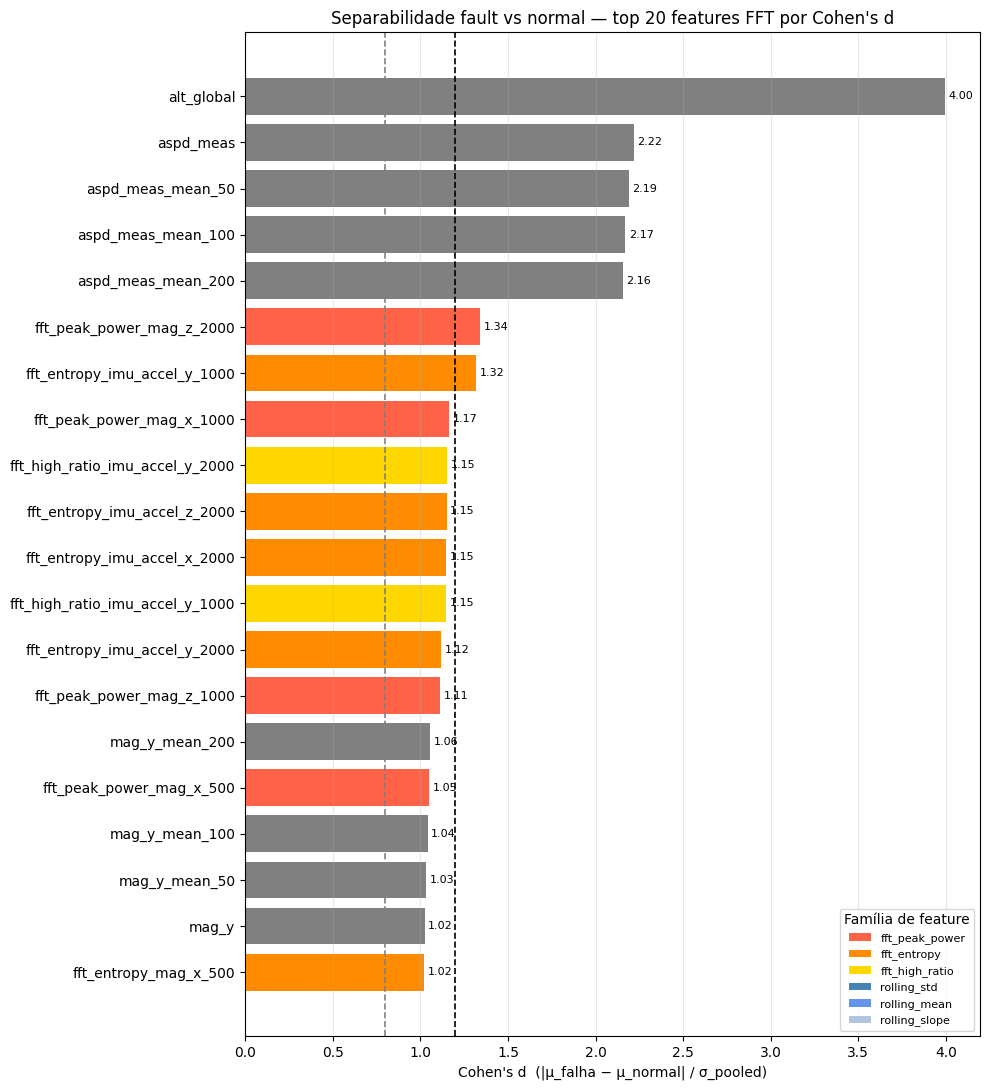

Distribuição por família nas top features:
  fft_entropy: 5
  fft_peak_power: 4
  fft_high_ratio: 2


In [4]:
# Calcula Cohen's d para todas as features e visualiza as selecionadas
normal_grp = df.loc[df[TARGET_COL] == 0, features]
fault_grp  = df.loc[df[TARGET_COL] == 1, features]

n0, n1 = len(normal_grp), len(fault_grp)
mean_diff  = (fault_grp.mean() - normal_grp.mean()).abs()
pooled_std = np.sqrt(
    ((n0 - 1) * normal_grp.std() ** 2 + (n1 - 1) * fault_grp.std() ** 2) / (n0 + n1 - 2)
).replace(0, np.nan)
cohens_d = (mean_diff / pooled_std).fillna(0)

top_scores = cohens_d[top_features].sort_values(ascending=True)

# Colorir por família de feature
def feat_color(name):
    if "fft_peak_power" in name:  return "tomato"
    if "fft_entropy"    in name:  return "darkorange"
    if "fft_high_ratio" in name:  return "gold"
    if "rolling_std"    in name:  return "steelblue"
    if "rolling_mean"   in name:  return "cornflowerblue"
    if "rolling_slope"  in name:  return "lightsteelblue"
    return "gray"

colors = [feat_color(f) for f in top_scores.index]

fig, ax = plt.subplots(figsize=(10, N_TOP_FEATURES * 0.5 + 1))
ax.barh(top_scores.index, top_scores.values, color=colors)
ax.axvline(0.8, color="gray",  linestyle="--", linewidth=1.2, label="d=0.8 (efeito grande)")
ax.axvline(1.2, color="black", linestyle="--", linewidth=1.2, label="d=1.2 (efeito muito grande)")
ax.set_xlabel("Cohen's d  (|μ_falha − μ_normal| / σ_pooled)")
ax.set_title(f"Separabilidade fault vs normal — top {N_TOP_FEATURES} features FFT por Cohen's d")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="x")

for i, (feat, val) in enumerate(zip(top_scores.index, top_scores.values)):
    ax.text(val + 0.02, i, f"{val:.2f}", va="center", fontsize=8)

# Legenda de cores
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="tomato",        label="fft_peak_power"),
    Patch(facecolor="darkorange",    label="fft_entropy"),
    Patch(facecolor="gold",          label="fft_high_ratio"),
    Patch(facecolor="steelblue",     label="rolling_std"),
    Patch(facecolor="cornflowerblue",label="rolling_mean"),
    Patch(facecolor="lightsteelblue",label="rolling_slope"),
]
ax.legend(handles=legend_elems, loc="lower right", fontsize=8, title="Família de feature")

plt.tight_layout()
plt.show()

# Contagem por família entre as top features
print("Distribuição por família nas top features:")
fam_counts = {}
for f in top_features:
    for fam in ["fft_peak_power", "fft_entropy", "fft_high_ratio",
                "rolling_std", "rolling_mean", "rolling_slope"]:
        if fam in f:
            fam_counts[fam] = fam_counts.get(fam, 0) + 1
for fam, count in sorted(fam_counts.items(), key=lambda x: -x[1]):
    print(f"  {fam}: {count}")

## Passo 2 — Sliding windows

Cada amostra é o achatamento dos últimos `window_size` timesteps.  
A ~200 Hz (frequência média após merge dos tópicos ROS), `window_size=20` captura ~0.1 s de contexto temporal.

In [5]:
X, y = create_windows(df, WINDOW_SIZE, top_features, TARGET_COL)
print(f"X shape: {X.shape}  (n_amostras, window_size × n_features = {WINDOW_SIZE} × {N_TOP_FEATURES})")
print(f"y shape: {y.shape}")
print(f"Positivos (falha): {y.sum()} ({y.mean()*100:.1f}%)")

X shape: (22011, 400)  (n_amostras, window_size × n_features = 20 × 20)
y shape: (22011,)
Positivos (falha): 3220.0 (14.6%)


## Passo 3 — Split temporal, escalonamento e treino

O split é **temporal** (sem shuffle): os primeiros 70% para treino, os últimos 30% para teste.

Após o split, um `RobustScaler` é ajustado **exclusivamente no treino** e aplicado em
ambos os conjuntos. O RobustScaler usa mediana e IQR em vez de média e desvio padrão,
evitando que janelas anômalas presentes no treino distorçam a referência de normalidade.

> Este passo corresponde ao nó `fft_fit_and_scale_node` do pipeline — **ausente no `model_training`
> original** e necessário porque features espectrais FFT têm escalas muito heterogêneas.

In [6]:
X_train, X_test, y_train, y_test = split_windows(X, y, train_ratio=TRAIN_RATIO)
timestamps = df[TIMESTAMP_COL].values[WINDOW_SIZE:]
split_idx  = int(len(timestamps) * TRAIN_RATIO)
ts_test    = timestamps[split_idx:]

print(f"Train: {X_train.shape} | {y_train.sum():.0f} falhas")
print(f"Test:  {X_test.shape}  | {y_test.sum():.0f} falhas")

Train: (15407, 400) | 0 falhas
Test:  (6604, 400)  | 3220 falhas


In [7]:
X_train_scaled, X_test_scaled, scaler = fit_and_scale(X_train, X_test)
print(f"Scaler: {scaler}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Scaler: RobustScaler()
X_train_scaled shape: (15407, 400)


In [8]:
model = train_isolation_forest(
    X_train_scaled,
    contamination=CONTAMINATION,
    n_estimators=N_ESTIMATORS,
    max_samples=MAX_SAMPLES,
    max_features=MAX_FEATURES,
)
print("Modelo treinado!")

Modelo treinado!


## Passo 4 — Avaliação

In [9]:
metrics = evaluate_model(model, X_test_scaled, y_test, ts_test)
print(f"Falha real:   {metrics.get('real_fault_time_s', 'N/A'):.2f}s")
print(f"Detecção:     {metrics.get('predicted_fault_time_s', 'N/A'):.2f}s")
print(f"Latência:     {metrics.get('detection_latency_s', 'N/A'):.2f}s")

Falha real:   115.31s
Detecção:     116.00s
Latência:     0.69s


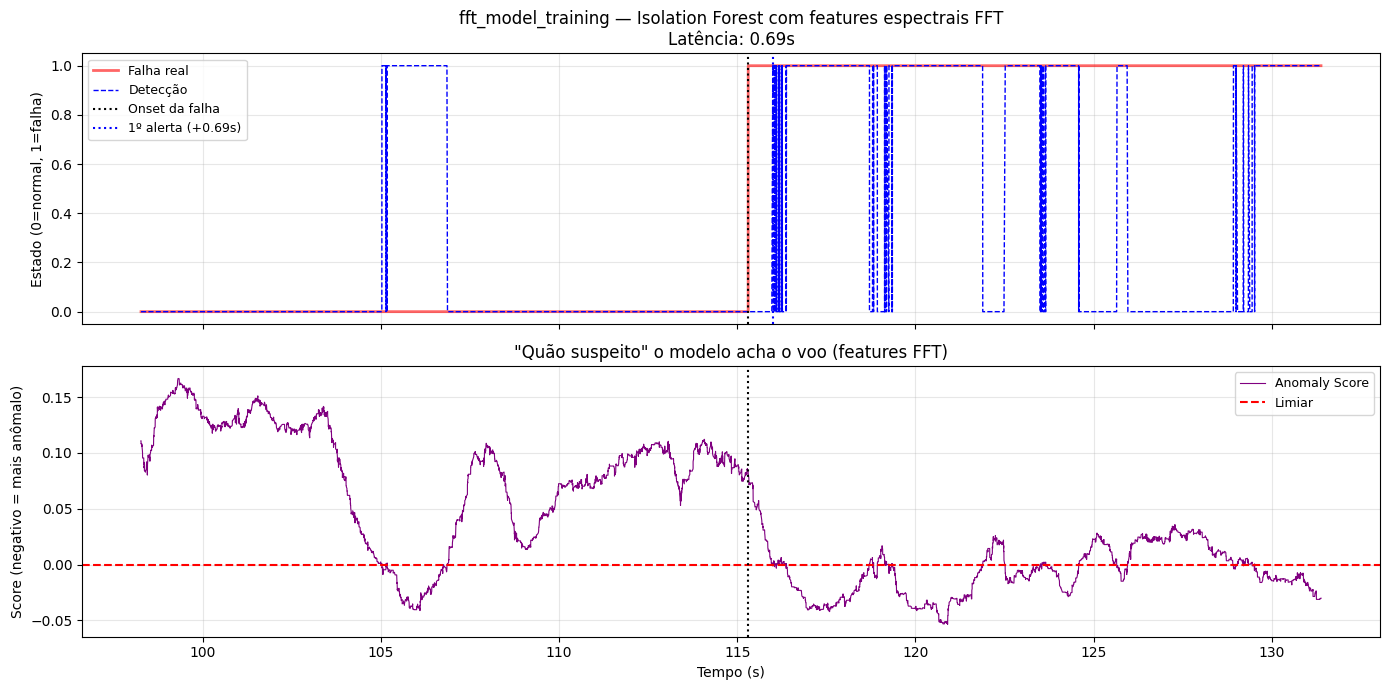

In [10]:
# Predições e scores
raw_preds = model.predict(X_test_scaled)
y_pred    = np.where(raw_preds == -1, 1, 0)
scores    = model.decision_function(X_test_scaled)

real_fault_time = metrics.get("real_fault_time_s")
pred_fault_time = metrics.get("predicted_fault_time_s")
latency         = metrics.get("detection_latency_s")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Painel 1: falha real vs detectada
axes[0].plot(ts_test, y_test, color="red",  alpha=0.6, linewidth=2, label="Falha real")
axes[0].plot(ts_test, y_pred, color="blue", linestyle="--", linewidth=1, label="Detecção")
if real_fault_time:
    axes[0].axvline(real_fault_time, color="black", linewidth=1.5, linestyle=":",
                    label="Onset da falha")
if pred_fault_time:
    axes[0].axvline(pred_fault_time, color="blue", linewidth=1.5, linestyle=":",
                    label=f"1º alerta (+{latency:.2f}s)" if latency is not None else "1º alerta")
axes[0].set_ylabel("Estado (0=normal, 1=falha)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(
    f"fft_model_training — Isolation Forest com features espectrais FFT\n"
    f"Latência: {latency:.2f}s" if latency is not None else
    "fft_model_training — Isolation Forest com features espectrais FFT"
)

# Painel 2: anomaly score
axes[1].plot(ts_test, scores, color="purple", linewidth=0.8, label="Anomaly Score")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="Limiar")
if real_fault_time:
    axes[1].axvline(real_fault_time, color="black", linewidth=1.5, linestyle=":")
axes[1].set_ylabel("Score (negativo = mais anômalo)")
axes[1].set_xlabel("Tempo (s)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('"Quão suspeito" o modelo acha o voo (features FFT)')

plt.tight_layout()
plt.show()

## Distribuição dos scores: treino vs teste

Visualiza a separação entre scores de janelas normais (treino) e do período de teste,
incluindo a região de falha. Um bom modelo deve ter scores de falha claramente
mais negativos que os de voo normal.

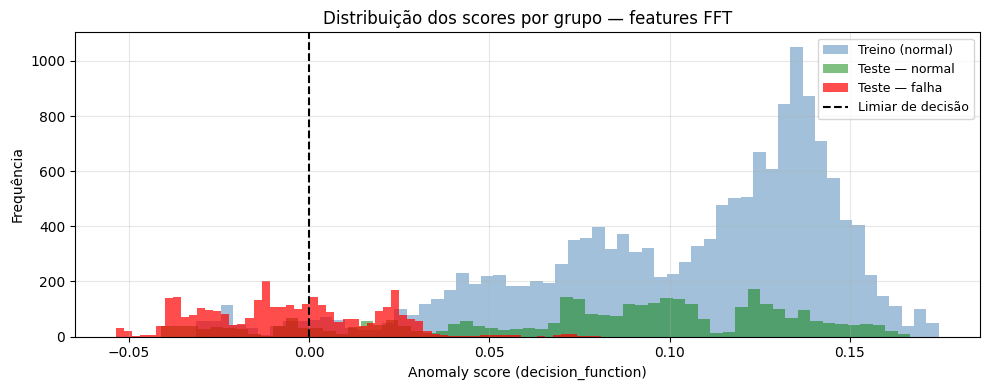

Score mediano — treino:       0.1174
Score mediano — teste normal: 0.0906
Score mediano — teste falha:  -0.0064


In [11]:
train_scores = model.decision_function(X_train_scaled)

fault_mask  = y_test == 1
normal_mask = y_test == 0

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(train_scores,           bins=60, alpha=0.5, color="steelblue", label="Treino (normal)")
ax.hist(scores[normal_mask],    bins=60, alpha=0.5, color="green",     label="Teste — normal")
ax.hist(scores[fault_mask],     bins=60, alpha=0.7, color="red",       label="Teste — falha")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Limiar de decisão")

ax.set_xlabel("Anomaly score (decision_function)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos scores por grupo — features FFT")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score mediano — treino:       {np.median(train_scores):.4f}")
print(f"Score mediano — teste normal: {np.median(scores[normal_mask]):.4f}")
print(f"Score mediano — teste falha:  {np.median(scores[fault_mask]):.4f}")

---
**Próximo:** `03_02_model2_fft.ipynb` → grid search de hiperparâmetros com features FFT para minimizar a latência de detecção.